In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
base_credit = pd.read_csv('credit_data.csv')
base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


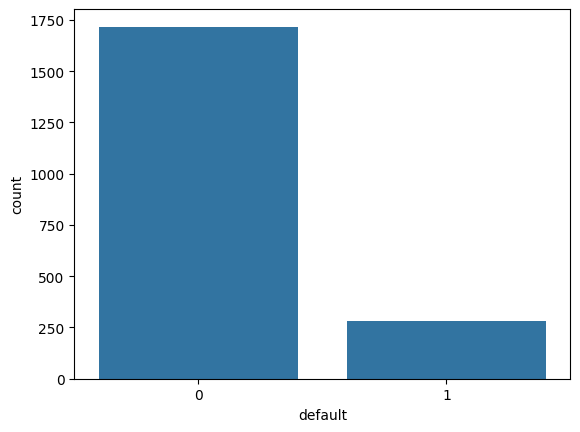

In [4]:
sns.countplot( x = base_credit['default']);

In [7]:
base_credit.isnull().sum()

clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

In [6]:
base_credit['age']= base_credit['age'].fillna(base_credit['age'].mean())

In [8]:
x_credit = base_credit.iloc[:, 1:4].values
y_credit = base_credit.iloc[:, 4].values

In [9]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
x_credit = scaler_credit.fit_transform(x_credit)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_credit_train, x_credit_test, y_credit_train, y_credit_test = train_test_split(x_credit, y_credit, test_size=0.25, random_state=0)

In [12]:
x_credit_train.shape, y_credit_train.shape

((1500, 3), (1500,))

In [13]:
x_credit_test, y_credit_test.shape

(array([[ 1.59301567, -1.30948327,  2.58262733],
        [ 0.99769755,  0.98032607,  0.84418709],
        [-0.42485257,  0.55209651, -1.15785286],
        ...,
        [ 1.37445674, -1.02049014, -1.12564819],
        [-1.57087737, -0.60915697, -0.36981671],
        [-1.03572293, -0.9059409 ,  0.04244312]]),
 (500,))

## Mudar Tipos Abaixo

In [92]:
from sklearn.svm import SVC
svm_credit = SVC(kernel='rbf', C = 2.2)
svm_credit.fit(x_credit_train, y_credit_train)

SVC(C=2.2)

In [93]:
previsoes = svm_credit.predict(x_credit_test)
#previsoes

In [94]:
# y_credit_test

In [95]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_test, previsoes)

0.988

0.988

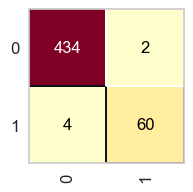

In [96]:
from yellowbrick.classifier import ConfusionMatrix
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(svm_credit)
cm.fit(x_credit_train, y_credit_train)
cm.score(x_credit_test, y_credit_test)